# SH0 Salvus Inversion With Illumination Outer Loop

This notebook merges the SH0 Salvus/acoustic inversion setup from `test_salvus_forward_solve_dispersion_SH0.ipynb` with the source-layout outer-loop ideas from `test_case_illumination.ipynb`.

Structure:
1. SH0 centered-domain model, sources, receivers, and Salvus data loading.
2. A plain inversion-only run, so results can be compared to the inversion notebook.
3. Outer-loop setup with three selectable `outer_loss` implementations:
   - nested FWI model-error objective,
   - nested FWI reference-data objective using fixed Salvus traces,
   - stochastic illumination objective.


In [1]:
import os

use_gpu = False  # Set True on a GPU server.

if use_gpu:
    os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
    import jax
    jax.config.update("jax_platform_name", "gpu")
else:
    import jax
    jax.config.update("jax_platform_name", "cpu")

In [2]:
import time as pytime
from pathlib import Path

import equinox as eqx
import numpy as np
import optax
from IPython.display import clear_output, display
from jax import jit, lax, random, value_and_grad, vmap
from jax import numpy as jnp
from jaxdf.operators import compose
from matplotlib import pyplot as plt
from jwave.signal_processing import smooth
from tqdm.auto import trange

from jax.example_libraries import optimizers
from hybridoed.forward import acoustic2D_cpml_minmem

/home/merciera/miniconda3/envs/hybridOED/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## SH0 Model And Acquisition Setup

Geometry is specified in centered meters, matching the Salvus convention. The acoustic solver receives grid-index coordinates after conversion.


In [3]:
# ---- physical domain (meters) ----
Lx, Ly = 1.1, 1.1
c_min = 1300.0
c_max = 2200.0
velocity = c_max
density = 2700.0

# ---- grid and stable time step ----
f0_max = 25e3
fmax = 2.0 * f0_max
PPW = 8

dx_req = c_min / (PPW * fmax)
dx = dy = dx_req

nx = int(np.floor(Lx / dx)) + 1
ny = int(np.floor(Ly / dy)) + 1
dx = Lx / (nx - 1)
dy = Ly / (ny - 1)

x_min_m, x_max_m = -Lx / 2, Lx / 2
y_min_m, y_max_m = -Ly / 2, Ly / 2


def x_to_i(x_m):
    return (np.asarray(x_m) - x_min_m) / dx


def y_to_i(y_m):
    return (np.asarray(y_m) - y_min_m) / dy


def xy_to_indices(xy_m):
    xy_m = np.asarray(xy_m, dtype=float)
    return np.stack([x_to_i(xy_m[..., 0]), y_to_i(xy_m[..., 1])], axis=-1)


def i_to_x(ix):
    return np.asarray(ix) * dx + x_min_m


def i_to_y(iy):
    return np.asarray(iy) * dy + y_min_m


dt_max = min(dx, dy) / (c_max * np.sqrt(2.0))
dt = 0.8 * dt_max

pml_thickness_m = 0.1
pml_width = max(4, int(round(pml_thickness_m / dx)))

T = 500e-6
n_steps = int(np.ceil(T / dt))
time = jnp.arange(n_steps) * dt

f0 = 25e3

print(f"nx, ny = {nx}, {ny} | dx = {dx * 1e3:.2f} mm | dt = {dt * 1e6:.2f} us")
print(f"pml_width = {pml_width} cells | n_steps = {n_steps} | total time = {n_steps * dt * 1e6:.1f} us")

nx, ny = 339, 339 | dx = 3.25 mm | dt = 0.84 us
pml_width = 31 cells | n_steps = 598 | total time = 500.4 us


In [4]:
# ---- model ----
true_model = jnp.full((nx, ny), velocity, dtype=jnp.float32)
homo_model = jnp.full((nx, ny), velocity, dtype=jnp.float32)

# Scatterer location and size from the Salvus setup.
scatterer_center_x_m = -0.05
scatterer_center_y_m = 0.05
scatterer_side_m = 0.055

scx0 = scatterer_center_x_m - scatterer_side_m / 2
scx1 = scatterer_center_x_m + scatterer_side_m / 2
scy0 = scatterer_center_y_m - scatterer_side_m / 2
scy1 = scatterer_center_y_m + scatterer_side_m / 2

ix0, ix1 = int(x_to_i(scx0)), int(x_to_i(scx1))
iy0, iy1 = int(y_to_i(scy0)), int(y_to_i(scy1))
true_model = true_model.at[ix0:ix1, iy0:iy1].set(c_min)

density_grid = jnp.full_like(true_model, density)
density_grid = density_grid.at[ix0:ix1, iy0:iy1].set(1180.0)
density_grid_homo = jnp.full_like(homo_model, density)

# ---- sources: four sides, 3 positions per side, matching the Salvus layout with offset ----
src_side_m = Lx / 2 - 0.2
src_inner_m = np.linspace(-0.25, 0.25, 3)

src_single_x0_m = [[-src_side_m, y] for y in src_inner_m]
src_single_y0_m = [[x, -src_side_m] for x in src_inner_m]
src_single_x1_m = [[src_side_m, y] for y in src_inner_m]
src_single_y1_m = [[x, src_side_m] for x in src_inner_m]

src_positions_m = np.array(
    src_single_x0_m + src_single_y0_m + src_single_x1_m + src_single_y1_m,
    dtype=float,
)
src_indices = jnp.array(xy_to_indices(src_positions_m), dtype=jnp.float32)
num_sources = src_indices.shape[0]

# ---- receivers ----
n_rx, n_ry = 30, 30
rec_x_m = np.linspace(-0.15, 0.15, n_rx)
rec_y_m = np.linspace(-0.15, 0.15, n_ry)
rec_xx, rec_yy = np.meshgrid(rec_x_m, rec_y_m, indexing="ij")
receiver_positions_m = np.stack([rec_xx.ravel(), rec_yy.ravel()], axis=1)
receiver_is = jnp.array(xy_to_indices(receiver_positions_m), dtype=jnp.float32)

print(f"sources = {src_indices.shape}, receivers = {receiver_is.shape}")

sources = (12, 2), receivers = (900, 2)


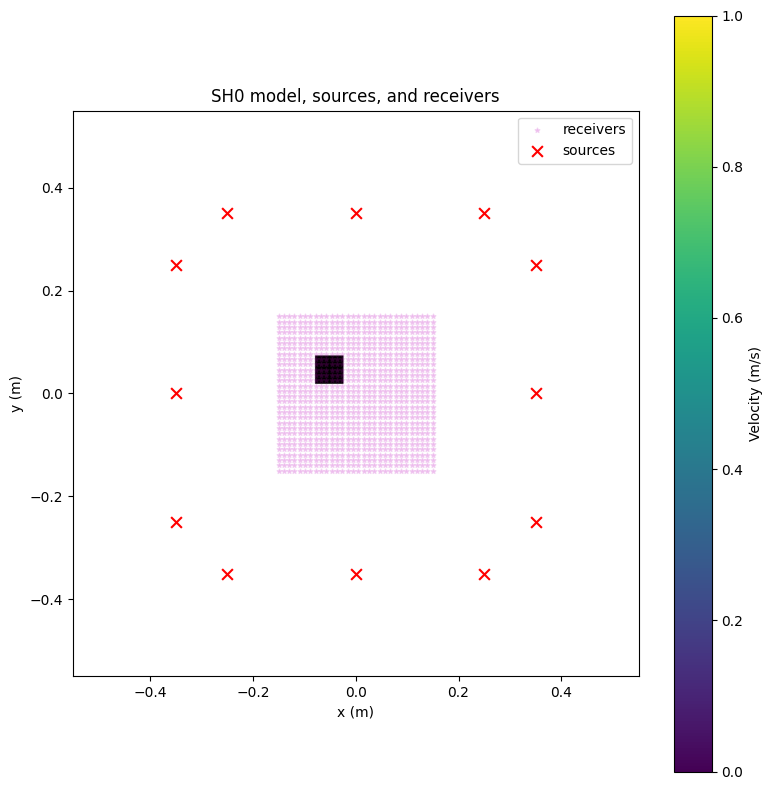

In [5]:
plt.figure(figsize=(8, 8))
plt.imshow(
    true_model.T,
    cmap="gray",
    origin="lower",
    extent=[x_min_m, x_max_m, y_min_m, y_max_m],
    aspect="equal",
)
plt.scatter(receiver_positions_m[:, 0], receiver_positions_m[:, 1], c="m", marker="*", s=12, alpha=0.15, label="receivers")
plt.scatter(src_positions_m[:, 0], src_positions_m[:, 1], c="r", marker="x", s=60, label="sources")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("SH0 model, sources, and receivers")
plt.legend()
plt.colorbar(label="Velocity (m/s)")
plt.tight_layout()
plt.show()

## Salvus Data Loading

The Salvus traces are interpolated onto the acoustic solver time axis and normalized trace-by-trace, matching the inversion notebook.


In [6]:
SALVUS_DATA_FILE = Path("all_traces_SH0_scat_absor.npz")


def _resolve_data_path(path):
    path = Path(path)
    if path.exists() or path.is_absolute():
        return path
    script_relative = Path.cwd() / path
    if script_relative.exists():
        return script_relative
    notebook_dir_relative = Path("src/scripts") / path
    if notebook_dir_relative.exists():
        return notebook_dir_relative
    return path


def interp_gather_to_time(gather, gather_time, target_time):
    gather = np.asarray(gather, dtype=float)
    gather_time = np.asarray(gather_time, dtype=float)
    target_time = np.asarray(target_time, dtype=float)

    if gather.shape[-1] == target_time.shape[-1]:
        return gather.astype(np.float32, copy=False)
    if gather_time.shape[-1] != gather.shape[-1]:
        gather_time = np.linspace(gather_time[0], gather_time[-1], gather.shape[-1])

    out = np.empty(gather.shape[:-1] + (target_time.shape[-1],), dtype=np.float32)
    flat_in = gather.reshape(-1, gather.shape[-1])
    flat_out = out.reshape(-1, target_time.shape[-1])
    for i, trace in enumerate(flat_in):
        flat_out[i] = np.interp(target_time, gather_time, trace)
    return out


salvus_out = np.load(_resolve_data_path(SALVUS_DATA_FILE))
salvus_traces_raw = salvus_out["all_traces"]
salvus_time = salvus_out["t"]

salvus_traces = interp_gather_to_time(salvus_traces_raw, salvus_time, np.asarray(time))
salvus_traces = jnp.asarray(salvus_traces, dtype=jnp.float32)
salvus_traces_normalized = salvus_traces / jnp.maximum(
    jnp.max(jnp.abs(salvus_traces), axis=2, keepdims=True),
    1e-12,
)

print("raw Salvus traces:", salvus_traces_raw.shape)
print("time-aligned Salvus traces:", salvus_traces_normalized.shape)
print("acoustic time axis:", time.shape)

raw Salvus traces: (12, 900, 3086)
time-aligned Salvus traces: (12, 900, 598)
acoustic time axis: (598,)


## Plain Inversion Setup

Run this section before the outer loop to reproduce a normal inversion with the SH0 model and Salvus data.


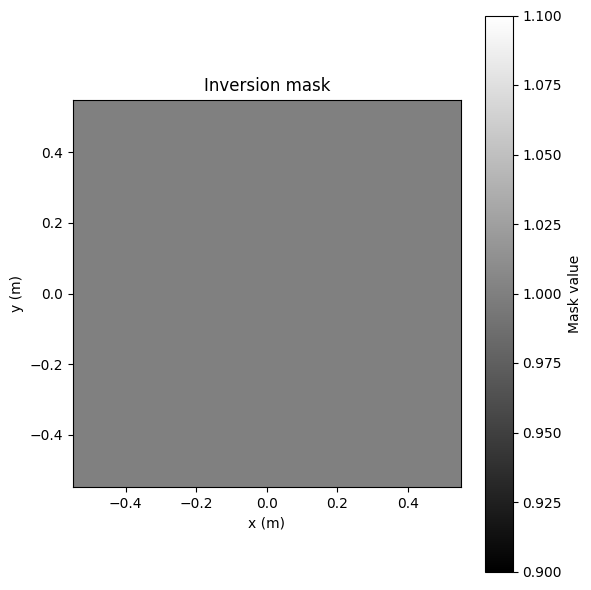

In [10]:
# Inversion mask: update only the central region, as in the SH0 inversion notebook.
mask = jnp.ones(true_model.shape, dtype=jnp.float32)
# extent_idx = int(0.275 / dx)
# mask = mask.at[
#     mask.shape[0] // 2 - extent_idx : mask.shape[0] // 2 + extent_idx + 1,
#     mask.shape[1] // 2 - extent_idx : mask.shape[1] // 2 + extent_idx + 1,
# ].set(1.0)

plt.figure(figsize=(6, 6))
plt.imshow(mask.T, cmap="gray", origin="lower", extent=[x_min_m, x_max_m, y_min_m, y_max_m], aspect="equal")
plt.title("Inversion mask")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.colorbar(label="Mask value")
plt.tight_layout()
plt.show()


def get_sound_speed(params):
    return params + compose(params)(jax.nn.sigmoid)


def smooth_fun(gradient):
    x = gradient * mask
    for _ in range(1):
        x = smooth(x)
    return x

In [11]:
def simulate_normalized_receivers(model, src_position, density_model=density_grid_homo):
    p_rec = acoustic2D_cpml_minmem(
        model,
        density_model,
        src_position,
        f0,
        dx,
        dy,
        dt,
        n_steps,
        receiver_is=receiver_is,
        output_wavefield=False,
        pml_width=pml_width,
        R_coeff=1e-6,
        m=3,
        kappa_max=3.0,
        alpha_max=None,
    )
    pred = p_rec[0].T  # [receiver, time]
    return pred / jnp.maximum(jnp.max(jnp.abs(pred), axis=1, keepdims=True), 1e-12)


def simulate_true_data(src_positions):
    return vmap(lambda src: simulate_normalized_receivers(true_model, src, density_grid))(src_positions)


def fwi(
    src_positions,
    observed_data=None,
    use_tqdm=True,
    num_steps_fwi=5000,
    display_every=10,
    learning_rate=25.0,
):
    """Run stochastic FWI.

    If observed_data is provided, it is used as fixed data. This is the Salvus
    inversion-only path. If observed_data is None, synthetic data are generated
    from true_model at the current src_positions. This keeps the outer-loop FWI
    objective differentiable with respect to source positions, as in the
    illumination notebook.
    """
    key = random.PRNGKey(42)
    key, _ = random.split(key)

    init_fun_fwi, update_fun_fwi, get_params_fwi = optimizers.adam(
        learning_rate, 0.9, 0.9
    )
    opt_state = init_fun_fwi(homo_model)

    if observed_data is None:
        data_for_fwi = simulate_true_data(src_positions)
    else:
        data_for_fwi = jnp.asarray(observed_data)

    available_src = jnp.arange(src_positions.shape[0])

    def loss_func(params, src_num):
        pred = simulate_normalized_receivers(get_sound_speed(params), src_positions[src_num])
        data = data_for_fwi[src_num]
        return jnp.mean((pred - data) ** 2)

    loss_with_grad = value_and_grad(loss_func, argnums=0)

    @jit
    def update_step(opt_state, key, step_idx):
        params = get_params_fwi(opt_state)
        key, subkey = random.split(key)
        src_num = random.choice(subkey, available_src)
        loss_value, gradient = loss_with_grad(params, src_num)
        gradient = smooth_fun(gradient)
        opt_state = update_fun_fwi(step_idx, gradient, opt_state)
        return opt_state, key, loss_value, src_num

    if use_tqdm:
        losses = []
        chosen_sources = []
        opt_state, key, loss_value, src_num = update_step(opt_state, key, 0)
        losses.append(float(loss_value.block_until_ready()))
        chosen_sources.append(int(src_num))

        pbar = trange(1, num_steps_fwi, desc="FWI", dynamic_ncols=True)
        for step_idx in pbar:
            opt_state, key, loss_value, src_num = update_step(opt_state, key, step_idx)
            if step_idx % display_every == 0:
                loss_scalar = float(loss_value.block_until_ready())
                pbar.set_postfix(loss=f"{loss_scalar:.3e}", src=int(src_num))
            else:
                loss_scalar = float(loss_value)
            losses.append(loss_scalar)
            chosen_sources.append(int(src_num))

        return get_params_fwi(opt_state), jnp.asarray(losses), jnp.asarray(chosen_sources)

    @jit
    def run_scan(opt_state, key):
        def body(carry, step_idx):
            opt_state, key = carry
            opt_state, key, loss_value, src_num = update_step(opt_state, key, step_idx)
            return (opt_state, key), (loss_value, src_num)

        (opt_state, key), (losses, chosen_sources) = lax.scan(
            body,
            (opt_state, key),
            jnp.arange(num_steps_fwi),
        )
        return opt_state, losses, chosen_sources

    opt_state, losses, chosen_sources = run_scan(opt_state, key)
    return get_params_fwi(opt_state), losses, chosen_sources


In [ ]:
# Plain inversion-only run. This matches the SH0 inversion notebook default.
# Reduce this value temporarily only for quick smoke tests.
baseline_num_steps_fwi = 120

baseline_model, baseline_losses, baseline_sources = fwi(
    src_indices,
    observed_data=salvus_traces_normalized,
    num_steps_fwi=baseline_num_steps_fwi,
    use_tqdm=True,
)

plt.figure(figsize=(6, 4))
plt.plot(np.asarray(baseline_losses))
plt.xlabel("FWI step")
plt.ylabel("MSE")
plt.title("Baseline Salvus inversion loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

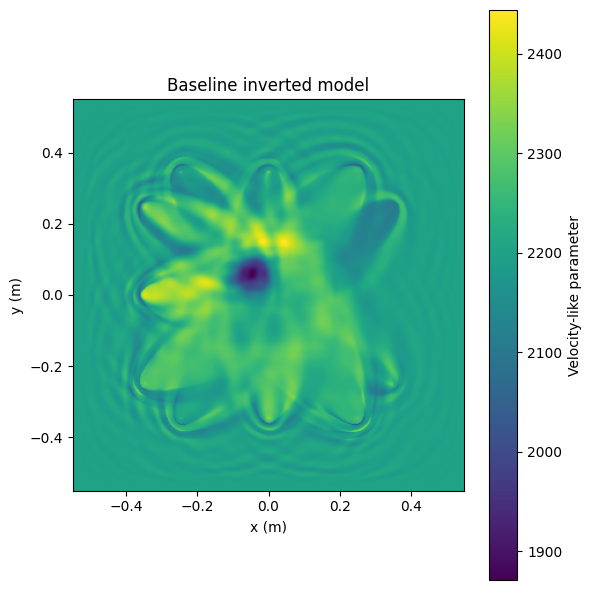

In [22]:
plt.figure(figsize=(6, 6))
plt.imshow(
    baseline_model.T,
    origin="lower",
    extent=[x_min_m, x_max_m, y_min_m, y_max_m],
    aspect="equal",
)
plt.title("Baseline inverted model")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.colorbar(label="Velocity-like parameter")
plt.tight_layout()
plt.show()

## Outer Loop Setup

This section adapts the outer loop from `test_case_illumination.ipynb` to the SH0 model and acquisition. Source positions are optimized in grid-index coordinates and clamped away from the PML.

Two outer losses are provided below. Select the active one by commenting/uncommenting the assignment cell.


In [12]:
source_modif = jnp.array(src_indices)
num_sources = source_modif.shape[0]

nx, ny = true_model.shape


@jit
def clamp_sources(src):
    i_clamped = jnp.clip(src[:, 0], pml_width, nx - 1 - pml_width)
    j_clamped = jnp.clip(src[:, 1], pml_width, ny - 1 - pml_width)
    return jnp.stack([i_clamped, j_clamped], axis=-1)


def source_indices_to_meters(src):
    src = np.asarray(jax.device_get(src))
    return np.stack([i_to_x(src[:, 0]), i_to_y(src[:, 1])], axis=-1)

### Outer loss option 1: nested FWI model error

This is the expensive objective from the illumination notebook: for candidate source positions, run an inner FWI and score the recovered model against `true_model`. Here synthetic data are generated from `true_model` at the candidate source positions to keep the objective differentiable with respect to source locations.


In [12]:
outer_fwi_steps = 80


def outer_loss_fwi_model_error(src_positions):
    src_positions = clamp_sources(src_positions)
    inverted_model, _, _ = fwi(
        src_positions,
        observed_data=None,
        use_tqdm=False,
        num_steps_fwi=outer_fwi_steps,
    )
    inverted_no_pml = inverted_model[pml_width:-pml_width, pml_width:-pml_width]
    true_no_pml = true_model[pml_width:-pml_width, pml_width:-pml_width]
    return jnp.mean((inverted_no_pml - true_no_pml) ** 2)

### Outer loss option 2: nested FWI fixed-reference data misfit

This objective follows the comparison logic from `test_salvus_forward_solve_dispersion_SH0.ipynb`: candidate sources are allowed to move only inside the inner inversion, but the outer score is computed by re-simulating the recovered model at the fixed Salvus source positions and fixed receivers. Those fixed-reference predictions are then compared to the fixed Salvus traces, so the data remain comparable even while the optimized sources move.


In [13]:
outer_reference_fwi_steps = 40

# Fixed reference acquisition: this must stay aligned with the Salvus NPZ file.
# The moving outer-loop sources are not compared directly to these data.
reference_src_indices = src_indices
reference_data = salvus_traces_normalized


def simulate_fixed_reference_data(model_params):
    """Simulate the recovered model on the fixed Salvus acquisition geometry."""
    model = get_sound_speed(model_params)
    return lax.map(
        lambda src: simulate_normalized_receivers(model, src, density_grid_homo),
        reference_src_indices,
    )


def outer_loss_reference_data(src_positions):
    """Outer objective based on fixed Salvus reference shots.

    The inner inversion uses the candidate moving sources with synthetic data
    generated at those same moving locations. After that inversion, the
    recovered model is evaluated at the fixed Salvus source/receiver geometry,
    and only that fixed-reference prediction is compared to the Salvus traces.
    """
    src_positions = clamp_sources(src_positions)
    inverted_params, _, _ = fwi(
        src_positions,
        observed_data=None,
        use_tqdm=False,
        num_steps_fwi=outer_reference_fwi_steps,
    )
    predicted_reference_data = simulate_fixed_reference_data(inverted_params)
    return jnp.mean((predicted_reference_data - reference_data) ** 2)


### Outer loss option 3: stochastic illumination objective

This is the illumination-style objective from `test_case_illumination.ipynb`. It estimates illumination with stochastic `J^T q` probes and optimizes source positions without running the full inner FWI at every outer step.


In [14]:
n_illum_probes = 16
illum_beta = 0.067
alpha_strength = 0.05
illum_eps = 1e-12


def simulate_one_source_for_illumination(model, src):
    p_rec = acoustic2D_cpml_minmem(
        model,
        density_grid_homo,
        src,
        f0,
        dx,
        dy,
        dt,
        n_steps,
        receiver_is=receiver_is,
        output_wavefield=False,
        pml_width=pml_width,
        R_coeff=1e-6,
        m=3,
        kappa_max=3.0,
        alpha_max=None,
    )
    return p_rec[0]


def jt_random_probe(model, src, key):
    """One stochastic contribution to diag(J^T J) for one source."""
    y, vjp_fun = jax.vjp(lambda m: simulate_one_source_for_illumination(m, src), model)
    q = random.rademacher(key, y.shape).astype(y.dtype)
    q = q / jnp.sqrt(q.size)
    g = vjp_fun(q)[0]
    return g**2


def outer_loss_illumination(src_positions):
    src_positions = clamp_sources(src_positions)
    key = random.PRNGKey(123)

    def one_source(src_num):
        src = src_positions[src_num]

        def one_probe(k):
            return jt_random_probe(homo_model, src, k)

        keys = random.split(random.fold_in(key, src_num), n_illum_probes)
        return jnp.mean(vmap(one_probe)(keys), axis=0)

    illum_sources = vmap(one_source)(jnp.arange(src_positions.shape[0]))
    illum = jnp.mean(illum_sources, axis=0)
    illum = smooth(illum)

    mean_illum = jnp.mean(illum)
    normalized_illum = illum / (mean_illum + illum_eps)
    uniformity_loss = jnp.var(normalized_illum)
    strength_loss = -jnp.log(mean_illum + illum_eps)

    # Alternative objective from the original notebook:
    # return -mean_illum + illum_beta * uniformity_loss
    return uniformity_loss + alpha_strength * strength_loss


### Select and run the outer loop

Set `outer_loss_name` to switch objectives. The reference-data option evaluates the recovered model on fixed Salvus source/receiver positions; keep `reference_src_indices` and `reference_data` aligned with the Salvus file. Because that objective contains a full inner inversion, the notebook uses an SPSA black-box outer step for `reference_data` to avoid differentiating through the full nested FWI graph.


In [14]:
# Select the active outer-loop objective.
# outer_loss_name = "fwi_model_error"
outer_loss_name = "reference_data"
# outer_loss_name = "illumination"

outer_loss_options = {
    "fwi_model_error": outer_loss_fwi_model_error,
    "reference_data": outer_loss_reference_data,
    "illumination": outer_loss_illumination,
}
outer_loss = outer_loss_options[outer_loss_name]

# The fixed-reference objective is too large to differentiate through the full
# nested FWI on this SH0 grid. Use a black-box SPSA outer gradient for that case.
use_spsa_outer_step = outer_loss_name == "reference_data"
outer_spsa_key = random.PRNGKey(20240508)
outer_spsa_eps = 1.0  # perturbation in grid-index units


@jit
def outer_step_grad(fargs, state):
    loss, grad_src = jax.value_and_grad(outer_loss)(fargs)
    updates, state = outer_optimiser.update(grad_src, state)
    fargs = optax.apply_updates(fargs, updates)
    fargs = clamp_sources(fargs)
    return fargs, state, loss


def outer_step_spsa(fargs, state, key):
    # Keep this wrapper outside jit so the two black-box inner inversions
    # are not fused into one huge XLA computation.
    delta = random.rademacher(key, fargs.shape).astype(fargs.dtype)
    fargs_plus = clamp_sources(fargs + outer_spsa_eps * delta)
    fargs_minus = clamp_sources(fargs - outer_spsa_eps * delta)

    loss_plus = outer_loss(fargs_plus)
    loss_minus = outer_loss(fargs_minus)
    loss = 0.5 * (loss_plus + loss_minus)
    grad_src = ((loss_plus - loss_minus) / (2.0 * outer_spsa_eps)) * delta

    updates, state = outer_optimiser.update(grad_src, state)
    fargs = optax.apply_updates(fargs, updates)
    fargs = clamp_sources(fargs)
    return fargs, state, loss


def outer_step(fargs, state):
    global outer_spsa_key
    if use_spsa_outer_step:
        outer_spsa_key, subkey = random.split(outer_spsa_key)
        return outer_step_spsa(fargs, state, subkey)
    return outer_step_grad(fargs, state)


NameError: name 'outer_loss_fwi_model_error' is not defined

In [16]:
def source_history_to_meters(history_grid):
    history_grid = np.asarray(history_grid)
    return np.stack(
        [i_to_x(history_grid[..., 0]), i_to_y(history_grid[..., 1])],
        axis=-1,
    )

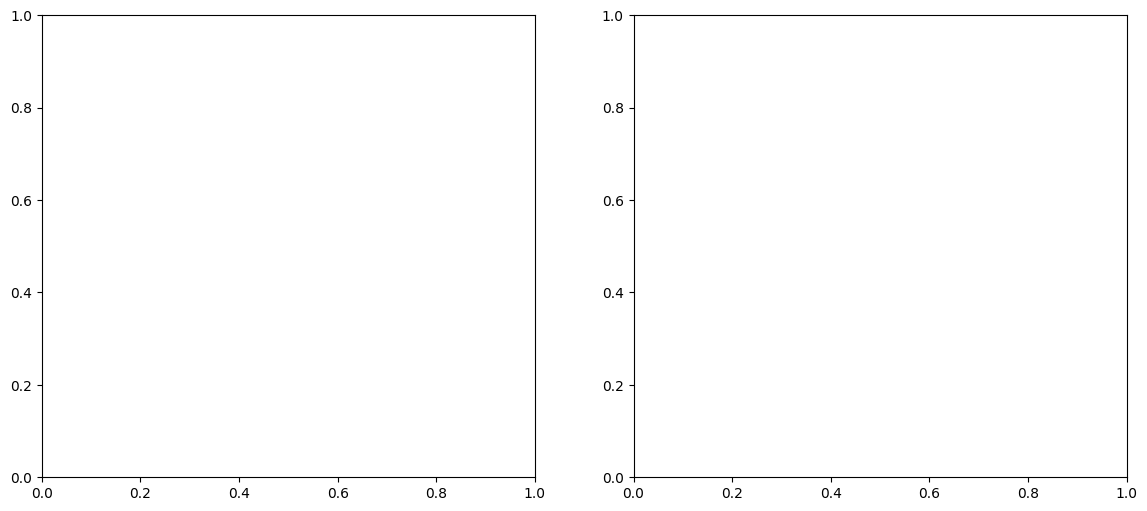

In [ ]:
outer_learning_rate = 2.0
n_steps_outer = 5

fargs = clamp_sources(source_modif)
outer_optimiser = optax.adam(learning_rate=outer_learning_rate)
opt_state = outer_optimiser.init(eqx.filter(fargs, eqx.is_array))

outer_losses = []
# Store source trajectories in solver grid indices. The first entry is the
# initial source layout, so movement is visible from the first outer step.
source_trajectories = [np.asarray(jax.device_get(fargs))]

fig, (ax_layout, ax_loss) = plt.subplots(1, 2, figsize=(14, 6))





for step in range(n_steps_outer):
    tic = pytime.time()
    fargs, opt_state, lossval = outer_step(fargs, opt_state)
    loss_float = float(jax.device_get(lossval))
    outer_losses.append(loss_float)
    source_trajectories.append(np.asarray(jax.device_get(fargs)))

    source_history_m = source_history_to_meters(source_trajectories)
    initial_sources_m = source_history_m[0]
    current_sources_m = source_history_m[-1]
    source_displacements_m = np.linalg.norm(current_sources_m - initial_sources_m, axis=1)

    ax_layout.clear()
    ax_layout.imshow(
        true_model.T,
        cmap="gray",
        origin="lower",
        extent=[x_min_m, x_max_m, y_min_m, y_max_m],
        aspect="equal",
    )
    ax_layout.scatter(
        receiver_positions_m[:, 0],
        receiver_positions_m[:, 1],
        c="g",
        marker="*",
        s=10,
        alpha=0.25,
        label="Receivers",
    )

    for src_id in range(source_history_m.shape[1]):
        path_m = source_history_m[:, src_id, :]
        ax_layout.plot(
            path_m[:, 0],
            path_m[:, 1],
            color="tab:orange",
            linewidth=1.4,
            alpha=0.75,
            label="Source history" if src_id == 0 else None,
        )

    ax_layout.scatter(
        initial_sources_m[:, 0],
        initial_sources_m[:, 1],
        facecolors="none",
        edgecolors="k",
        marker="o",
        s=55,
        linewidths=1.2,
        label="Initial sources",
    )
    ax_layout.scatter(
        current_sources_m[:, 0],
        current_sources_m[:, 1],
        c="r",
        marker="x",
        s=70,
        linewidths=1.8,
        label="Current sources",
    )
    ax_layout.set_title(f"Outer step {step} | max source move = {source_displacements_m.max():.4f} m")
    ax_layout.set_xlabel("x (m)")
    ax_layout.set_ylabel("y (m)")
    ax_layout.set_xlim(x_min_m, x_max_m)
    ax_layout.set_ylim(y_min_m, y_max_m)
    ax_layout.legend(loc="upper right", fontsize=8)

    ax_loss.clear()
    ax_loss.plot(np.arange(1, len(outer_losses) + 1), outer_losses, color="tab:blue")
    ax_loss.set_xlabel("Outer iteration")
    ax_loss.set_ylabel("Outer loss")
    ax_loss.grid(True, alpha=0.3)

    clear_output(wait=True)
    display(fig)
    print(
        f"step={step:03d}, loss={loss_float:.6e}, "
        f"max_move={source_displacements_m.max():.4e} m, "
        f"elapsed={pytime.time() - tic:.2f}s"
    )

plt.close(fig)
print("Final outer loss:", outer_losses[-1])


In [ ]:
# Save outer-loop results for later analysis.
np.savez(
    "salvus_SH0_outerloop_results.npz",
    final_sources_grid=np.asarray(jax.device_get(fargs)),
    final_sources_m=source_indices_to_meters(fargs),
    source_trajectories=np.asarray(source_trajectories),
    outer_losses=np.asarray(outer_losses),
    baseline_model=np.asarray(jax.device_get(baseline_model)) if "baseline_model" in globals() else None,
    baseline_losses=np.asarray(jax.device_get(baseline_losses)) if "baseline_losses" in globals() else None,
)
print("Saved salvus_SH0_outerloop_results.npz")

## Load And Plot Saved Outer-Loop Results

Use these cells after an outer-loop run, or in a fresh notebook session after running the setup cells. They load the saved NPZ, plot the source trajectory and loss, then rerun a final inversion with the optimized source layout to compare the inverted model before and after source optimization.


In [7]:
OUTER_RESULTS_FILE = Path("salvus_SH0_outerloop_results_more_iterations.npz")


def resolve_results_path(path):
    path = Path(path)
    if path.exists() or path.is_absolute():
        return path
    script_relative = Path.cwd() / path
    if script_relative.exists():
        return script_relative
    notebook_dir_relative = Path("src/scripts") / path
    if notebook_dir_relative.exists():
        return notebook_dir_relative
    raise FileNotFoundError(f"Could not find results file: {path}")


def optional_npz_array(npz, key):
    if key not in npz.files:
        return None
    value = npz[key]
    if value.shape == () and value.dtype == object and value.item() is None:
        return None
    return value


outer_results_path = resolve_results_path(OUTER_RESULTS_FILE)
outer_results = np.load(outer_results_path, allow_pickle=True)
print("Loaded:", outer_results_path)
print("Keys:", outer_results.files)

loaded_source_trajectories_grid = outer_results["source_trajectories"]
loaded_outer_losses = outer_results["outer_losses"]
loaded_final_sources_grid = outer_results["final_sources_grid"]
loaded_final_sources_m = optional_npz_array(outer_results, "final_sources_m")
loaded_baseline_model = optional_npz_array(outer_results, "baseline_model")
loaded_baseline_losses = optional_npz_array(outer_results, "baseline_losses")

print("source_trajectories:", loaded_source_trajectories_grid.shape)
print("outer_losses:", loaded_outer_losses.shape)
print("final_sources_grid:", loaded_final_sources_grid.shape)
if loaded_baseline_model is not None:
    print("baseline_model:", loaded_baseline_model.shape)


Loaded: salvus_SH0_outerloop_results_more_iterations.npz
Keys: ['final_sources_grid', 'final_sources_m', 'source_trajectories', 'outer_losses', 'baseline_model', 'baseline_losses', 'outer_learning_rate', 'n_steps_outer', 'outer_loss_name', 'outer_reference_fwi_steps']
source_trajectories: (26, 12, 2)
outer_losses: (25,)
final_sources_grid: (12, 2)
baseline_model: (339, 339)


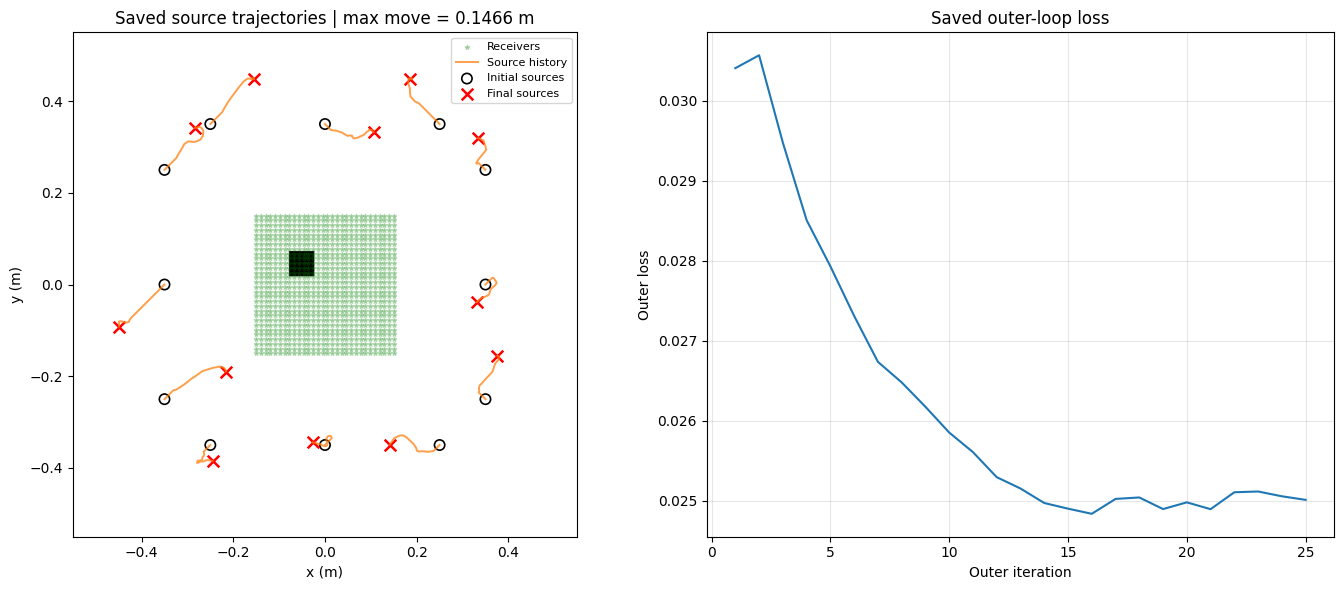

In [17]:
loaded_source_history_m = source_history_to_meters(loaded_source_trajectories_grid)
loaded_initial_sources_m = loaded_source_history_m[0]
loaded_current_sources_m = loaded_source_history_m[-1]
loaded_source_displacements_m = np.linalg.norm(
    loaded_current_sources_m - loaded_initial_sources_m,
    axis=1,
)

fig, (ax_layout, ax_loss) = plt.subplots(1, 2, figsize=(14, 6))

ax_layout.imshow(
    true_model.T,
    cmap="gray",
    origin="lower",
    extent=[x_min_m, x_max_m, y_min_m, y_max_m],
    aspect="equal",
)
ax_layout.scatter(
    receiver_positions_m[:, 0],
    receiver_positions_m[:, 1],
    c="g",
    marker="*",
    s=10,
    alpha=0.25,
    label="Receivers",
)
for src_id in range(loaded_source_history_m.shape[1]):
    path_m = loaded_source_history_m[:, src_id, :]
    ax_layout.plot(
        path_m[:, 0],
        path_m[:, 1],
        color="tab:orange",
        linewidth=1.4,
        alpha=0.75,
        label="Source history" if src_id == 0 else None,
    )
ax_layout.scatter(
    loaded_initial_sources_m[:, 0],
    loaded_initial_sources_m[:, 1],
    facecolors="none",
    edgecolors="k",
    marker="o",
    s=55,
    linewidths=1.2,
    label="Initial sources",
)
ax_layout.scatter(
    loaded_current_sources_m[:, 0],
    loaded_current_sources_m[:, 1],
    c="r",
    marker="x",
    s=70,
    linewidths=1.8,
    label="Final sources",
)
ax_layout.set_title(f"Saved source trajectories | max move = {loaded_source_displacements_m.max():.4f} m")
ax_layout.set_xlabel("x (m)")
ax_layout.set_ylabel("y (m)")
ax_layout.set_xlim(x_min_m, x_max_m)
ax_layout.set_ylim(y_min_m, y_max_m)
ax_layout.legend(loc="upper right", fontsize=8)

ax_loss.plot(np.arange(1, len(loaded_outer_losses) + 1), loaded_outer_losses, color="tab:blue")
ax_loss.set_xlabel("Outer iteration")
ax_loss.set_ylabel("Outer loss")
ax_loss.set_title("Saved outer-loop loss")
ax_loss.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()


FWI: 100%|██████████| 119/119 [06:23<00:00,  3.22s/it, loss=5.548e-03, src=4]


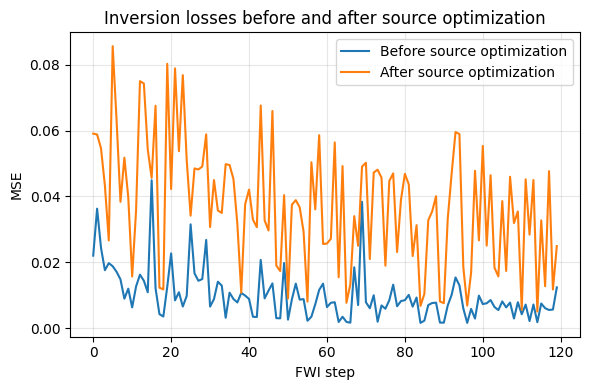

In [20]:
# Rerun the final inversion with the optimized source layout from the NPZ.
# Keep this equal to baseline_num_steps_fwi for a fair before/after comparison.
optimized_num_steps_fwi = baseline_num_steps_fwi
optimized_sources_grid = jnp.asarray(loaded_final_sources_grid, dtype=jnp.float32)

optimized_model, optimized_losses, optimized_chosen_sources = fwi(
    optimized_sources_grid,
    observed_data=salvus_traces_normalized,
    num_steps_fwi=optimized_num_steps_fwi,
    use_tqdm=True,
)

plt.figure(figsize=(6, 4))
if loaded_baseline_losses is not None:
    plt.plot(np.asarray(loaded_baseline_losses), label="Before source optimization")
plt.plot(np.asarray(optimized_losses), label="After source optimization")
plt.xlabel("FWI step")
plt.ylabel("MSE")
plt.title("Inversion losses before and after source optimization")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


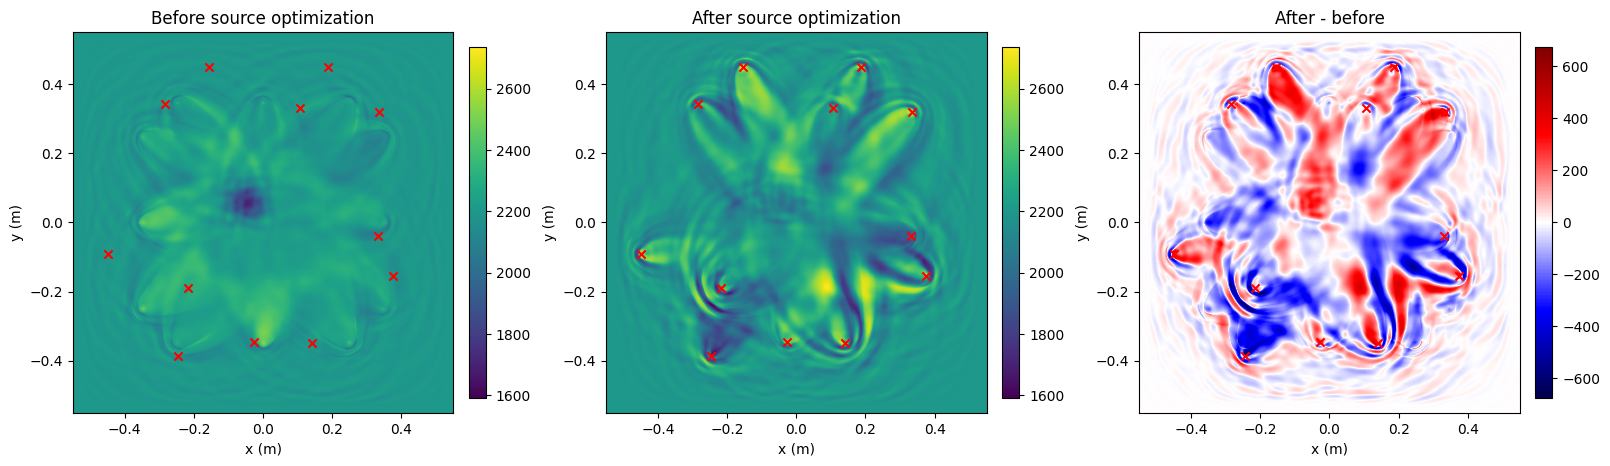

In [21]:
if loaded_baseline_model is None:
    if "baseline_model" in globals():
        loaded_baseline_model = np.asarray(jax.device_get(baseline_model))
    else:
        raise RuntimeError(
            "No baseline model was found in the NPZ or current notebook state. "
            "Run the baseline inversion cell first, or save a new NPZ with baseline_model."
        )

optimized_model_np = np.asarray(jax.device_get(optimized_model))
baseline_model_np = np.asarray(loaded_baseline_model)

vmin = min(float(np.nanmin(baseline_model_np)), float(np.nanmin(optimized_model_np)))
vmax = max(float(np.nanmax(baseline_model_np)), float(np.nanmax(optimized_model_np)))

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
model_panels = [
    (baseline_model_np, "Before source optimization"),
    (optimized_model_np, "After source optimization"),
    (optimized_model_np - baseline_model_np, "After - before"),
]

for ax, (model_to_plot, title) in zip(axes, model_panels):
    if "After - before" in title:
        diff_vmax = max(float(np.nanmax(np.abs(model_to_plot))), 1e-12)
        im = ax.imshow(
            model_to_plot.T,
            origin="lower",
            extent=[x_min_m, x_max_m, y_min_m, y_max_m],
            aspect="equal",
            cmap="seismic",
            vmin=-diff_vmax,
            vmax=diff_vmax,
        )
    else:
        im = ax.imshow(
            model_to_plot.T,
            origin="lower",
            extent=[x_min_m, x_max_m, y_min_m, y_max_m],
            aspect="equal",
            vmin=vmin,
            vmax=vmax,
        )
    ax.scatter(loaded_current_sources_m[:, 0], loaded_current_sources_m[:, 1], c="r", marker="x", s=35)
    ax.set_title(title)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.show()


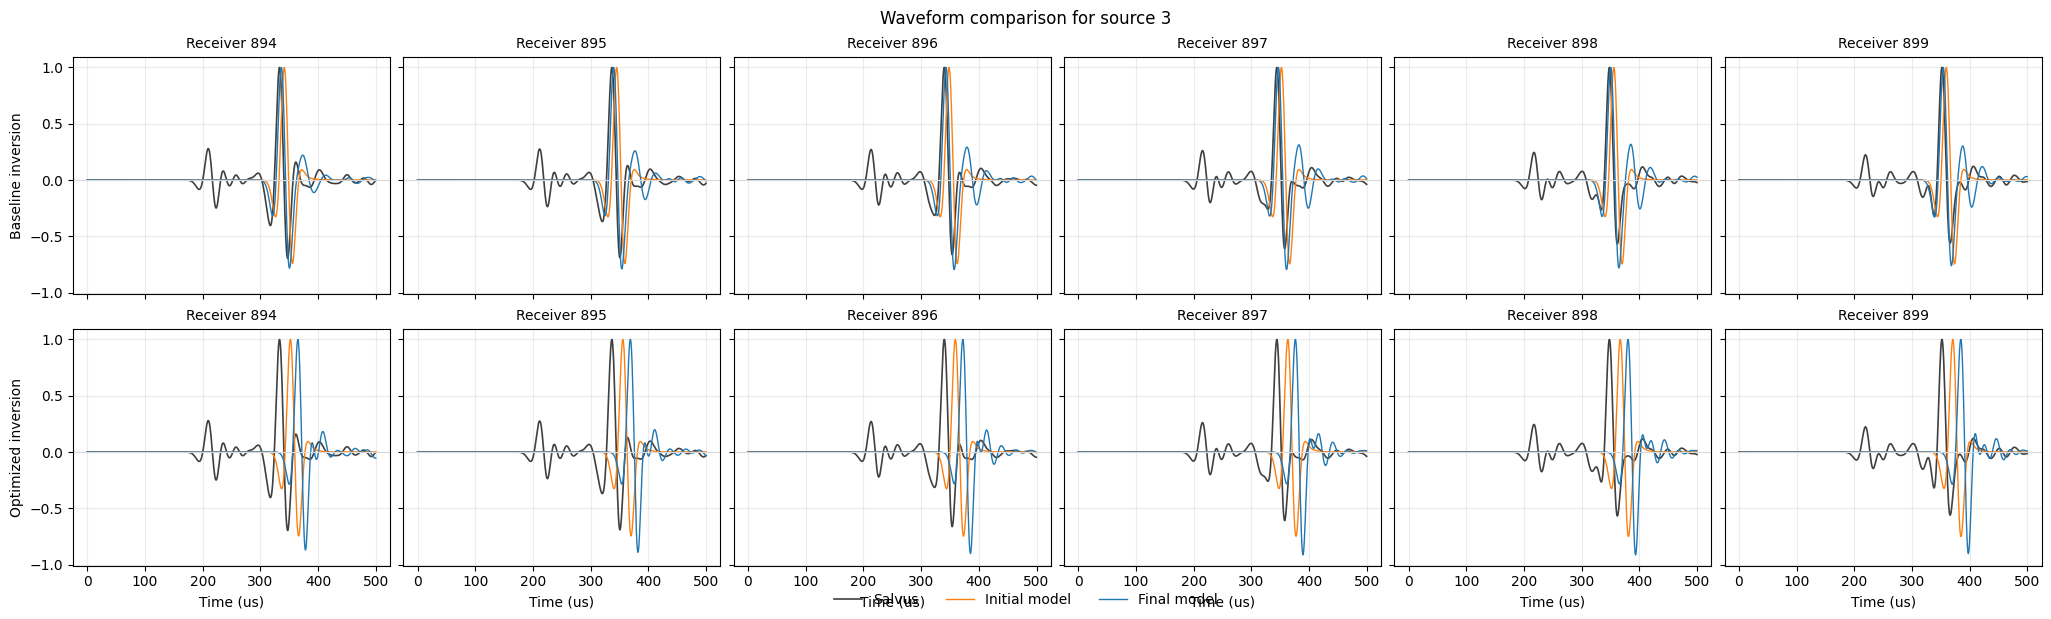

Baseline inversion: initial gather MSE = 3.934e-02, final gather MSE = 1.419e-02
Optimized inversion: initial gather MSE = 8.543e-02, final gather MSE = 5.204e-02


In [26]:
# Compare baseline and optimized inversion waveforms at the initial and final models.
# Change waveform_source_id or waveform_receiver_ids to inspect a different gather.
waveform_source_id = 3
waveform_receiver_ids = None  # Example: [0, 150, 450, 899]
num_waveform_receivers = 6

if "optimized_model" not in globals():
    raise RuntimeError("Run the optimized inversion cell before comparing waveforms.")

if "loaded_baseline_model" not in globals() or loaded_baseline_model is None:
    if "baseline_model" in globals():
        loaded_baseline_model = np.asarray(jax.device_get(baseline_model))
    else:
        raise RuntimeError(
            "No baseline final model is available. Run the baseline inversion cell first, "
            "or load an NPZ that contains baseline_model."
        )

if "loaded_final_sources_grid" in globals():
    optimized_sources_for_waveforms = jnp.asarray(loaded_final_sources_grid, dtype=jnp.float32)
elif "optimized_sources_grid" in globals():
    optimized_sources_for_waveforms = jnp.asarray(optimized_sources_grid, dtype=jnp.float32)
else:
    raise RuntimeError("Run the saved-results loading cell or define optimized_sources_grid first.")

baseline_final_model = jnp.asarray(loaded_baseline_model, dtype=jnp.float32)
optimized_final_model = jnp.asarray(jax.device_get(optimized_model), dtype=jnp.float32)
initial_model_for_waveforms = get_sound_speed(homo_model)

waveform_sets = {
    "Baseline inversion": {
        "source": src_indices[waveform_source_id],
        "initial": simulate_normalized_receivers(initial_model_for_waveforms, src_indices[waveform_source_id]),
        "final": simulate_normalized_receivers(get_sound_speed(baseline_final_model), src_indices[waveform_source_id]),
    },
    "Optimized inversion": {
        "source": optimized_sources_for_waveforms[waveform_source_id],
        "initial": simulate_normalized_receivers(
            initial_model_for_waveforms,
            optimized_sources_for_waveforms[waveform_source_id],
        ),
        "final": simulate_normalized_receivers(
            get_sound_speed(optimized_final_model),
            optimized_sources_for_waveforms[waveform_source_id],
        ),
    },
}

observed_gather = np.asarray(jax.device_get(salvus_traces_normalized[waveform_source_id]))
time_us = np.asarray(jax.device_get(time)) * 1e6

if waveform_receiver_ids is None:
    receiver_energy = np.max(np.abs(observed_gather), axis=1)
    waveform_receiver_ids = np.argsort(receiver_energy)[-num_waveform_receivers:]
    waveform_receiver_ids = np.sort(waveform_receiver_ids)
else:
    waveform_receiver_ids = np.asarray(waveform_receiver_ids, dtype=int)

fig, axes = plt.subplots(
    len(waveform_sets),
    len(waveform_receiver_ids),
    figsize=(3.4 * len(waveform_receiver_ids), 5.8),
    sharex=True,
    sharey=True,
    constrained_layout=True,
    squeeze=False,
)

for row, (inversion_name, gathers) in enumerate(waveform_sets.items()):
    initial_gather = np.asarray(jax.device_get(gathers["initial"]))
    final_gather = np.asarray(jax.device_get(gathers["final"]))
    for col, receiver_id in enumerate(waveform_receiver_ids):
        ax = axes[row, col]
        ax.plot(time_us, observed_gather[receiver_id], color="0.25", linewidth=1.2, label="Salvus")
        ax.plot(time_us, initial_gather[receiver_id], color="tab:orange", linewidth=1.0, label="Initial model")
        ax.plot(time_us, final_gather[receiver_id], color="tab:blue", linewidth=1.0, label="Final model")
        ax.axhline(0.0, color="0.85", linewidth=0.8)
        ax.set_title(f"Receiver {receiver_id}", fontsize=10)
        if col == 0:
            ax.set_ylabel(inversion_name)
        if row == len(waveform_sets) - 1:
            ax.set_xlabel("Time (us)")
        ax.grid(True, alpha=0.25)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False)
fig.suptitle(f"Waveform comparison for source {waveform_source_id}", y=1.04)
plt.show()

for inversion_name, gathers in waveform_sets.items():
    initial_mse = np.mean((np.asarray(jax.device_get(gathers["initial"])) - observed_gather) ** 2)
    final_mse = np.mean((np.asarray(jax.device_get(gathers["final"])) - observed_gather) ** 2)
    print(f"{inversion_name}: initial gather MSE = {initial_mse:.3e}, final gather MSE = {final_mse:.3e}")
